In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('train.csv')
df

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
...,...,...,...,...,...,...
404285,404285,433578,379845,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404286,404286,18840,155606,Do you believe there is life after death?,Is it true that there is life after death?,1
404287,404287,537928,537929,What is one coin?,What's this coin?,0
404288,404288,537930,537931,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0


In [3]:
import re
from bs4 import BeautifulSoup

In [4]:
def preprocesses(q):
    q=str(q).strip().lower()

    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')

    q.replace('[math]','')

    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)


    contractions = { 
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted=[]

    for word in q.split(' '):
        if word in contractions:
            word=contractions[word]
        q_decontracted.append(word)
    q=' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")

    q=BeautifulSoup(q)
    q=q.get_text()

    pattern=re.compile('\W')
    q=re.sub(pattern,' ',q)

    return q


    


In [5]:
newdf=df.sample(40000)
newdf

,id,qid1,qid2,question1,question2,is_duplicate
6310,6310,12369,12370,How do foreigners who have settled in India fe...,Is India a better place for foreign people to ...,0
215080,215080,320860,320861,Is Gst.gov.in website down?,"What are the best slogans based on the theme ""...",0
388327,388327,520704,233244,Is there any way to see Mac OS X Finder's colo...,What would run better: OS X on a PC or Windows...,0
100755,100755,167060,167061,What is your concept of time?,What is time concept?,0
70130,70130,120927,120928,I read that Finnish uses cardinal directions (...,Is this Wikipedia sentence true?,0
...,...,...,...,...,...,...
103127,103127,170526,170527,What do you think foreigners think Brazilians ...,What do you think foreigners think about Brazil?,0
253834,253834,368437,368438,What do Indians think about Iran?,What do Indians think of Iran and Iranians?,0
106534,106534,175470,123608,What advice would you give to an IIT aspirant?,What advice or tips would you give to a first ...,0
96318,96318,160459,160460,Why do water conduct electricity?,How can I open E-Cell (Entrepreneurship Cell) ...,0


In [6]:
print(preprocesses("I've already! wasn't <b>done</b>?"))

i have already  was not done 


In [7]:
newdf['question1']=newdf['question1'].apply(preprocesses)
newdf['question2']=newdf['question2'].apply(preprocesses)
newdf.head()

,id,qid1,qid2,question1,question2,is_duplicate
6310,6310,12369,12370,how do foreigners who have settled in india fe...,is india a better place for foreign people to ...,0
215080,215080,320860,320861,is gst gov in website down,what are the best slogans based on the theme ...,0
388327,388327,520704,233244,is there any way to see mac os x finder s colo...,what would run better os x on a pc or windows...,0
100755,100755,167060,167061,what is your concept of time,what is time concept,0
70130,70130,120927,120928,i read that finnish uses cardinal directions ...,is this wikipedia sentence true,0


In [8]:
newdf.shape

(40000, 6)

In [9]:
newdf['q1_len']=newdf['question1'].str.len()
newdf['q2_len']=newdf['question2'].str.len()

In [10]:
newdf['q1_num_words']=newdf['question1'].apply(lambda x: len(x.split(' ')))
newdf['q2_num_words']=newdf['question2'].apply(lambda x: len(x.split(' ')))

In [11]:
newdf

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
6310,6310,12369,12370,how do foreigners who have settled in india fe...,is india a better place for foreign people to ...,0,61,53,12,11
215080,215080,320860,320861,is gst gov in website down,what are the best slogans based on the theme ...,0,27,80,7,24
388327,388327,520704,233244,is there any way to see mac os x finder s colo...,what would run better os x on a pc or windows...,0,66,56,16,16
100755,100755,167060,167061,what is your concept of time,what is time concept,0,29,21,7,5
70130,70130,120927,120928,i read that finnish uses cardinal directions ...,is this wikipedia sentence true,0,140,32,27,6
...,...,...,...,...,...,...,...,...,...,...
103127,103127,170526,170527,what do you think foreigners think brazilians ...,what do you think foreigners think about brazil,0,82,48,13,9
253834,253834,368437,368438,what do indians think about iran,what do indians think of iran and iranians,0,33,43,7,9
106534,106534,175470,123608,what advice would you give to an iit aspirant,what advice or tips would you give to a first ...,0,46,63,10,14
96318,96318,160459,160460,why do water conduct electricity,how can i open e cell entrepreneurship cell ...,0,33,60,6,14


In [12]:
def common_words(row):
    w1=set(map(lambda x : x.strip().lower(),row['question1'].split(' ')))
    w2=set(map(lambda x : x.strip().lower(),row['question2'].split(' ')))
    return len(w1&w2)

In [13]:
def total_words(row):
    w1=set(map(lambda x : x.strip().lower(),row['question1'].split(' ')))
    w2=set(map(lambda x : x.strip().lower(),row['question2'].split(' ')))
    return len(w1)+len(w2)

In [14]:
newdf['common_words']=newdf.apply(common_words,axis=1)
newdf['total_words']=newdf.apply(total_words,axis=1)
newdf

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words
6310,6310,12369,12370,how do foreigners who have settled in india fe...,is india a better place for foreign people to ...,0,61,53,12,11,2,22
215080,215080,320860,320861,is gst gov in website down,what are the best slogans based on the theme ...,0,27,80,7,24,1,24
388327,388327,520704,233244,is there any way to see mac os x finder s colo...,what would run better os x on a pc or windows...,0,66,56,16,16,6,29
100755,100755,167060,167061,what is your concept of time,what is time concept,0,29,21,7,5,5,12
70130,70130,120927,120928,i read that finnish uses cardinal directions ...,is this wikipedia sentence true,0,140,32,27,6,5,29
...,...,...,...,...,...,...,...,...,...,...,...,...
103127,103127,170526,170527,what do you think foreigners think brazilians ...,what do you think foreigners think about brazil,0,82,48,13,9,8,17
253834,253834,368437,368438,what do indians think about iran,what do indians think of iran and iranians,0,33,43,7,9,6,16
106534,106534,175470,123608,what advice would you give to an iit aspirant,what advice or tips would you give to a first ...,0,46,63,10,14,8,24
96318,96318,160459,160460,why do water conduct electricity,how can i open e cell entrepreneurship cell ...,0,33,60,6,14,1,17


In [17]:
newdf['word_share']=newdf['common_words']/newdf['total_words']

In [16]:
from nltk.corpus import stopwords

In [18]:
def fetch_token_features(row):
    q1=row['question1']
    q2=row['question2']
    SAFE_DIV=0.0001
    STOP_WORDS=stopwords.words('english')

    token_features=[0.0]*8

    q1_tokens=q1.split(' ')
    q2_tokens=q2.split(' ')
    if len(q1_tokens)==0 or len(q2_tokens)==0:
        return token_features
    q1_words=set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words=set([word for word in q2_tokens if word not in STOP_WORDS])

    q1_stops=set([word for word in q1_tokens if word  in STOP_WORDS])
    q2_stops=set([word for word in q2_tokens if word  in STOP_WORDS])

    common_word_count=len(q1_words.intersection(q2_words))
    common_stop_count=len(q1_stops.intersection(q2_stops))
    common_token_count=len(set(q1_tokens).intersection(set(q2_tokens)))

    
    token_features[0]=common_word_count/(min(len(q1_words),len(q2_words))+SAFE_DIV)
    token_features[1]=common_word_count/(max(len(q1_words),len(q2_words))+SAFE_DIV)
    token_features[2]=common_stop_count/(min(len(q1_stops),len(q2_stops))+SAFE_DIV)
    token_features[3]=common_stop_count/(max(len(q1_stops),len(q2_stops))+SAFE_DIV)
    token_features[4]=common_token_count/(min(len(q1_tokens),len(q2_tokens))+SAFE_DIV)
    token_features[5]=common_token_count/(max(len(q1_tokens),len(q2_tokens))+SAFE_DIV)

    token_features[6]=int(q1_tokens[-1]==q2_tokens[-1])
    token_features[7]=int(q2_tokens[0]==q2_tokens[0])

    return token_features
    

    
    

In [19]:
token_features=newdf.apply(fetch_token_features,axis=1)
newdf['cwc_min']=list(map(lambda x : x[0] , token_features))
newdf['cwc_max']=list(map(lambda x : x[1] , token_features))
newdf['csc_min']=list(map(lambda x : x[2] , token_features))
newdf['csc_max']=list(map(lambda x : x[3] , token_features))
newdf['ctc_min']=list(map(lambda x : x[4] , token_features))
newdf['ctc_max']=list(map(lambda x : x[5] , token_features))
newdf['first_word_eq']=list(map(lambda x : x[6] , token_features))
newdf['last_word_eq']=list(map(lambda x : x[7] , token_features))
newdf

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,total_words,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,first_word_eq,last_word_eq
6310,6310,12369,12370,how do foreigners who have settled in india fe...,is india a better place for foreign people to ...,0,61,53,12,11,...,22,0.090909,0.399992,0.285710,0.000000,0.000000,0.181817,0.166665,1,1
215080,215080,320860,320861,is gst gov in website down,what are the best slogans based on the theme ...,0,27,80,7,24,...,24,0.041667,0.249994,0.083333,0.000000,0.000000,0.142855,0.041666,1,1
388327,388327,520704,233244,is there any way to see mac os x finder s colo...,what would run better os x on a pc or windows...,0,66,56,16,16,...,29,0.206897,0.555549,0.499995,0.249994,0.166664,0.374998,0.374998,1,1
100755,100755,167060,167061,what is your concept of time,what is time concept,0,29,21,7,5,...,12,0.416667,0.999967,0.999967,0.999950,0.499988,0.999980,0.714276,1,1
70130,70130,120927,120928,i read that finnish uses cardinal directions ...,is this wikipedia sentence true,0,140,32,27,6,...,29,0.172414,0.749981,0.187499,0.999950,0.285710,0.833319,0.185184,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103127,103127,170526,170527,what do you think foreigners think brazilians ...,what do you think foreigners think about brazil,0,82,48,13,9,...,17,0.470588,0.999975,0.799984,0.999975,0.999975,0.888879,0.615380,1,1
253834,253834,368437,368438,what do indians think about iran,what do indians think of iran and iranians,0,33,43,7,9,...,16,0.375000,0.999975,0.799984,0.666644,0.499988,0.857131,0.666659,1,1
106534,106534,175470,123608,what advice would you give to an iit aspirant,what advice or tips would you give to a first ...,0,46,63,10,14,...,24,0.333333,0.833319,0.555549,0.749981,0.599988,0.799992,0.571424,1,1
96318,96318,160459,160460,why do water conduct electricity,how can i open e cell entrepreneurship cell ...,0,33,60,6,14,...,17,0.058824,0.249994,0.166664,0.000000,0.000000,0.166664,0.071428,1,1


In [20]:
import distance
def fetch_length_features(row):
    q1=row['question1']
    q2=row['question2']

    length_features=[0.0]*3

    q1_tokens=q1.split(' ')
    q2_tokens=q2.split(' ')
    if len(q1_tokens)==0 or len(q2_tokens)==0 : return length_features

    length_features[0]=abs(len(q1_tokens)-len(q2_tokens))
    length_features[1]=(len(q1_tokens)+len(q2_tokens))/2

    strs=list(distance.lcsubstrings(q1,q2))
    length_features[2]=len(strs[0])/(min(len(q1),len(q2))+1)

    return length_features

In [21]:
length_features=newdf.apply(fetch_length_features,axis=1)

newdf['abs_len_diff']=list(map(lambda x: x[0],length_features))
newdf['mean_len']=list(map(lambda x: x[1],length_features))
newdf['longest_substring_ratio']=list(map(lambda x : x[2],length_features))
newdf

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,first_word_eq,last_word_eq,abs_len_diff,mean_len,longest_substring_ratio
6310,6310,12369,12370,how do foreigners who have settled in india fe...,is india a better place for foreign people to ...,0,61,53,12,11,...,0.285710,0.000000,0.000000,0.181817,0.166665,1,1,1,11.5,0.148148
215080,215080,320860,320861,is gst gov in website down,what are the best slogans based on the theme ...,0,27,80,7,24,...,0.083333,0.000000,0.000000,0.142855,0.041666,1,1,17,15.5,0.107143
388327,388327,520704,233244,is there any way to see mac os x finder s colo...,what would run better os x on a pc or windows...,0,66,56,16,16,...,0.499995,0.249994,0.166664,0.374998,0.374998,1,1,0,16.0,0.157895
100755,100755,167060,167061,what is your concept of time,what is time concept,0,29,21,7,5,...,0.999967,0.999950,0.499988,0.999980,0.714276,1,1,2,6.0,0.409091
70130,70130,120927,120928,i read that finnish uses cardinal directions ...,is this wikipedia sentence true,0,140,32,27,6,...,0.187499,0.999950,0.285710,0.833319,0.185184,1,1,21,16.5,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103127,103127,170526,170527,what do you think foreigners think brazilians ...,what do you think foreigners think about brazil,0,82,48,13,9,...,0.799984,0.999975,0.999975,0.888879,0.615380,1,1,4,11.0,0.755102
253834,253834,368437,368438,what do indians think about iran,what do indians think of iran and iranians,0,33,43,7,9,...,0.799984,0.666644,0.499988,0.857131,0.666659,1,1,2,8.0,0.647059
106534,106534,175470,123608,what advice would you give to an iit aspirant,what advice or tips would you give to a first ...,0,46,63,10,14,...,0.555549,0.749981,0.599988,0.799992,0.571424,1,1,4,12.0,0.425532
96318,96318,160459,160460,why do water conduct electricity,how can i open e cell entrepreneurship cell ...,0,33,60,6,14,...,0.166664,0.000000,0.000000,0.166664,0.071428,1,1,8,10.0,0.088235


In [22]:
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):
    q1=row['question1']
    q2=row['question2']
    fuzzy_features=[0.0]*4

    fuzzy_features[0]=fuzz.QRatio(q1,q2)
    fuzzy_features[1]=fuzz.partial_ratio(q1,q2)
    fuzzy_features[2]=fuzz.token_sort_ratio(q1,q2)
    fuzzy_features[3]=fuzz.token_set_ratio(q1,q2)
    return fuzzy_features

C:\Users\SHREYA\anaconda3\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [23]:
fuzzy_features=newdf.apply(fetch_fuzzy_features,axis=1)

newdf['fuzz_ratio']=list(map(lambda x: x[0],fuzzy_features))
newdf['fuzz_partial_ratio']=list(map(lambda x: x[1],fuzzy_features))
newdf['token_sort_ratio']=list(map(lambda x: x[2],fuzzy_features))
newdf['token_set_ratio']=list(map(lambda x: x[3],fuzzy_features))
newdf

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,first_word_eq,last_word_eq,abs_len_diff,mean_len,longest_substring_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
6310,6310,12369,12370,how do foreigners who have settled in india fe...,is india a better place for foreign people to ...,0,61,53,12,11,...,0.166665,1,1,1,11.5,0.148148,34,40,55,60
215080,215080,320860,320861,is gst gov in website down,what are the best slogans based on the theme ...,0,27,80,7,24,...,0.041666,1,1,17,15.5,0.107143,23,41,28,30
388327,388327,520704,233244,is there any way to see mac os x finder s colo...,what would run better os x on a pc or windows...,0,66,56,16,16,...,0.374998,1,1,0,16.0,0.157895,42,40,52,56
100755,100755,167060,167061,what is your concept of time,what is time concept,0,29,21,7,5,...,0.714276,1,1,2,6.0,0.409091,67,81,83,100
70130,70130,120927,120928,i read that finnish uses cardinal directions ...,is this wikipedia sentence true,0,140,32,27,6,...,0.185184,1,1,21,16.5,0.333333,31,56,34,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103127,103127,170526,170527,what do you think foreigners think brazilians ...,what do you think foreigners think about brazil,0,82,48,13,9,...,0.615380,1,1,4,11.0,0.755102,73,88,73,100
253834,253834,368437,368438,what do indians think about iran,what do indians think of iran and iranians,0,33,43,7,9,...,0.666659,1,1,2,8.0,0.647059,76,88,76,90
106534,106534,175470,123608,what advice would you give to an iit aspirant,what advice or tips would you give to a first ...,0,46,63,10,14,...,0.571424,1,1,4,12.0,0.425532,73,76,69,85
96318,96318,160459,160460,why do water conduct electricity,how can i open e cell entrepreneurship cell ...,0,33,60,6,14,...,0.071428,1,1,8,10.0,0.088235,18,33,27,29


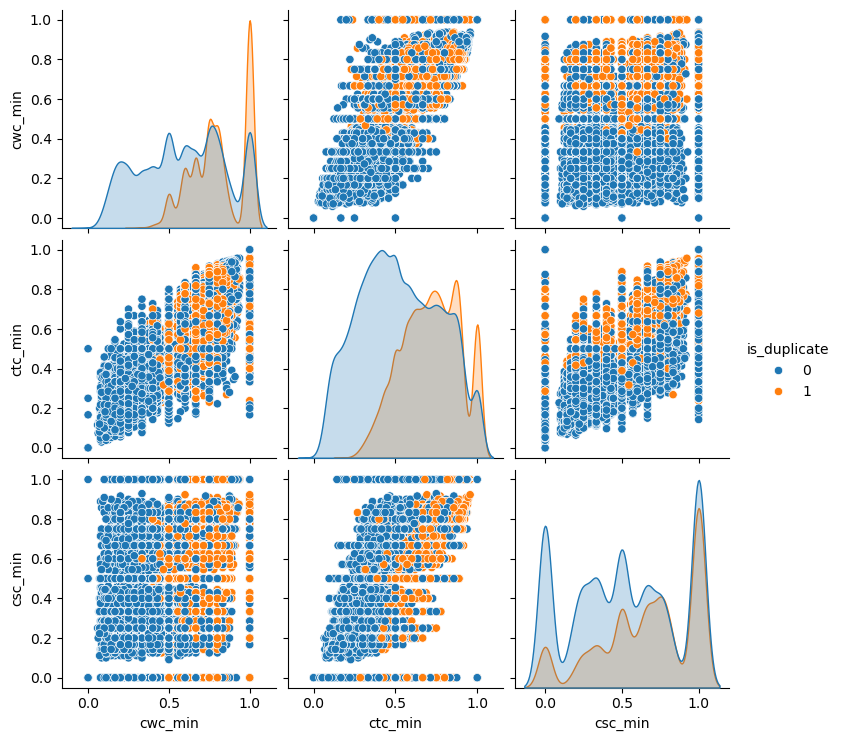

In [24]:
import seaborn as sns
sns.pairplot(newdf[['cwc_min','ctc_min','csc_min','is_duplicate']],hue='is_duplicate')

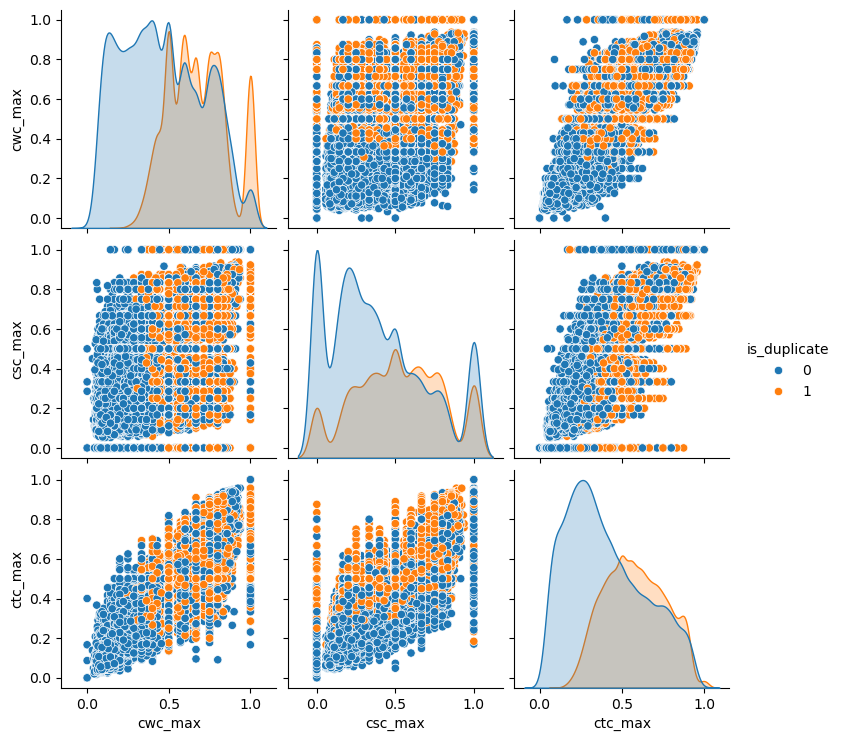

In [25]:
sns.pairplot(newdf[['cwc_max','csc_max','ctc_max','is_duplicate']],hue='is_duplicate')

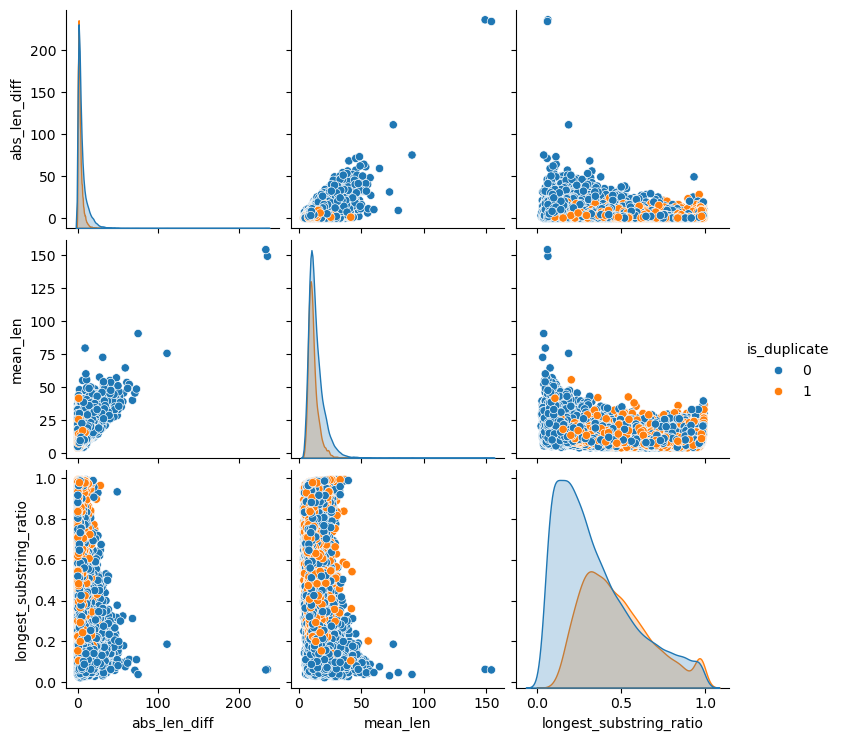

In [26]:
sns.pairplot(newdf[['abs_len_diff','mean_len','longest_substring_ratio','is_duplicate']],hue='is_duplicate')

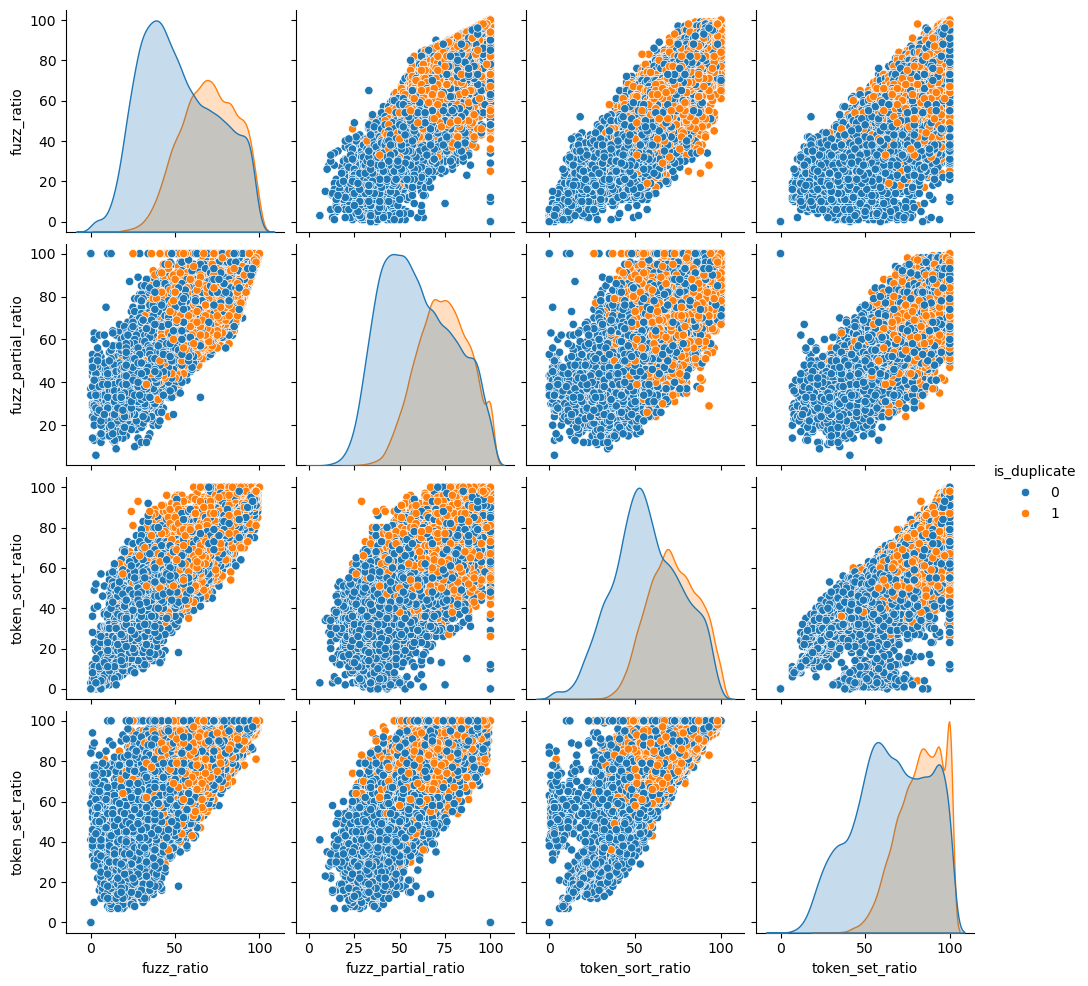

In [27]:
sns.pairplot(newdf[['fuzz_ratio','fuzz_partial_ratio','token_sort_ratio','token_set_ratio', 'is_duplicate']],hue='is_duplicate')

In [28]:
ques_df=newdf[['question1','question2']]
questions=list(ques_df['question1'])+list(ques_df['question2'])
from sklearn.feature_extraction.text import TfidfVectorizer
vec=TfidfVectorizer(max_features=3000)
q1_arr,q2_arr=np.vsplit(vec.fit_transform(questions).toarray(),2)

In [29]:
tempdf1=pd.DataFrame(q1_arr,index=ques_df.index)
tempdf2=pd.DataFrame(q2_arr,index=ques_df.index)
tempdf=pd.concat([tempdf1,tempdf2],axis=1)
tempdf

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
6310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
215080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
388327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
100755,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
70130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103127,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.186811,0.0,0.0,0.0,0.0,0.0,0.0
253834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
106534,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.176626,0.0,0.0,0.0,0.0,0.0,0.0
96318,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
import pickle 
with open('vec.pkl','wb') as f:
    pickle.dump(vec,f)

In [31]:
finaldf=newdf.drop(columns=['id','qid1','qid2','question1','question2'])
finaldf

,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words,word_share,cwc_min,cwc_max,...,ctc_max,first_word_eq,last_word_eq,abs_len_diff,mean_len,longest_substring_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
6310,0,61,53,12,11,2,22,0.090909,0.399992,0.285710,...,0.166665,1,1,1,11.5,0.148148,34,40,55,60
215080,0,27,80,7,24,1,24,0.041667,0.249994,0.083333,...,0.041666,1,1,17,15.5,0.107143,23,41,28,30
388327,0,66,56,16,16,6,29,0.206897,0.555549,0.499995,...,0.374998,1,1,0,16.0,0.157895,42,40,52,56
100755,0,29,21,7,5,5,12,0.416667,0.999967,0.999967,...,0.714276,1,1,2,6.0,0.409091,67,81,83,100
70130,0,140,32,27,6,5,29,0.172414,0.749981,0.187499,...,0.185184,1,1,21,16.5,0.333333,31,56,34,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103127,0,82,48,13,9,8,17,0.470588,0.999975,0.799984,...,0.615380,1,1,4,11.0,0.755102,73,88,73,100
253834,0,33,43,7,9,6,16,0.375000,0.999975,0.799984,...,0.666659,1,1,2,8.0,0.647059,76,88,76,90
106534,0,46,63,10,14,8,24,0.333333,0.833319,0.555549,...,0.571424,1,1,4,12.0,0.425532,73,76,69,85
96318,0,33,60,6,14,1,17,0.058824,0.249994,0.166664,...,0.071428,1,1,8,10.0,0.088235,18,33,27,29


In [32]:
finaldf=pd.concat([finaldf,tempdf],axis=1)
finaldf.head()

,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words,word_share,cwc_min,cwc_max,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
6310,0,61,53,12,11,2,22,0.090909,0.399992,0.285710,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
215080,0,27,80,7,24,1,24,0.041667,0.249994,0.083333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
388327,0,66,56,16,16,6,29,0.206897,0.555549,0.499995,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100755,0,29,21,7,5,5,12,0.416667,0.999967,0.999967,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
70130,0,140,32,27,6,5,29,0.172414,0.749981,0.187499,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(finaldf.iloc[:,1:].values,finaldf.iloc[:,0].values,test_size=0.2,random_state=42)

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [41]:
rf1=RandomForestClassifier()
rf1.fit(x_train,y_train)
print(accuracy_score(y_test,rf1.predict(x_test)))

0.782875


In [45]:
type(finaldf.iloc[:,0].values)

numpy.ndarray

In [46]:
import pickle
with open('q_pair_detection.pkl','wb')as f:
    pickle.dump(rf1,f)